# SAMPLE_1 · 서울 화재 인명피해 예측 (01 · 모델 학습)

**목표**: 화재 데이터를 학습해 이진분류 모델(`model.pkl`)을 만들어 02 폴더로 넘긴다.

**표준 워크플로우 (8단계)**: 로드 → EDA → 결측치 → 타겟분리·인코딩 → 분할(stratify) → 학습 → 평가(ROC-AUC) → 저장

### 데이터 출처
- 데이터셋: **소방청_화재발생 정보** (전국 화재 조사 데이터, 2020.01 ~ 2024.12)
- 출처: **공공데이터포털 (data.go.kr)** — https://www.data.go.kr/data/15044003/fileData.do
- 제공기관: **소방청** · 분류체계: 공공질서및안전 - 안전관리 · 파일: **CSV**
- **이용허락범위: 제한 없음** (포털 상세페이지 표기 기준) — 출처만 밝히면 자유롭게 활용 가능
- 받는 법: 위 페이지 → 다운로드 (CSV, 로그인 불필요). 원본은 전국 191,510건
- 이 폴더의 `data/소방청_화재발생정보_서울.csv` 는 원본에서 **서울특별시만 추린 26,760건** (시도 열은 상수라 제외)
- 공공데이터를 학습(교육) 목적으로 사용합니다.

## 1단계. 라이브러리 & 데이터 로드
필요한 라이브러리를 불러오고 CSV 를 읽는다.
이 데이터에는 인명피해 **인원수**가 있으므로, **1명이라도 있으면 1(있음), 없으면 0(없음)** 인 이진 타겟을 만든다.

In [1]:
import pandas as pd, numpy as np, json, joblib
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve

plt.rcParams['font.family'] = 'Malgun Gothic'   # 그래프 한글이 깨지지 않게 (Windows)
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('data/소방청_화재발생정보_서울.csv', encoding='cp949')

# 정답(타겟) 만들기 : 인명피해가 1명이라도 있으면 1, 없으면 0
TARGET = '인명피해여부'
LABELS = ['인명피해 없음', '인명피해 있음']
df[TARGET] = (pd.to_numeric(df['인명피해(명)소계'], errors='coerce').fillna(0) > 0).astype(int)

print('데이터 크기(행, 열):', df.shape)
df.head()

데이터 크기(행, 열): (26760, 15)


,화재발생년원일,시군구,화재유형,발화요인대분류,발화요인소분류,인명피해(명)소계,사망,부상,재산피해소계,부동산,동산,장소대분류,장소중분류,장소소분류,인명피해여부
0,2020-01-01 0:33,성북구,기타(쓰레기 화재등),부주의,담배꽁초,0,0,0,326,0.0,326.0,기타,야외,쓰레기,0
1,2020-01-01 2:46,금천구,기타(쓰레기 화재등),부주의,가연물 근접방치,6,0,6,68,0.0,68.0,기타,야외,기타야외,1
2,2020-01-01 4:14,중랑구,"건축,구조물",전기적 요인,절연열화에 의한 단락,0,0,0,193,83.0,110.0,생활서비스,일상서비스,기타 일상서비스,0
3,2020-01-01 4:36,관악구,"건축,구조물",부주의,"불씨,불꽃,화원방치",0,0,0,38,0.0,38.0,생활서비스,음식점,"치킨,족발",0
4,2020-01-01 5:02,용산구,기타(쓰레기 화재등),부주의,기타(부주의),0,0,0,31,0.0,31.0,기타,야외,기타야외,0


## 2단계. EDA - 데이터 파악
타겟 분포(균형 여부)와 결측치를 확인한다. **여기서 본 것이 뒤의 전처리·평가지표 선택을 결정한다.**

[타겟 분포]
인명피해여부
0    25709
1     1051
Name: count, dtype: int64
인명피해 발생 비율: 0.0393

[결측치 개수]
화재발생년원일        0
시군구            0
화재유형           0
발화요인대분류        0
발화요인소분류        0
인명피해(명)소계      0
사망             0
부상             0
재산피해소계         0
부동산          855
동산           855
장소대분류          0
장소중분류          0
장소소분류          0
인명피해여부         0
dtype: int64

[범주형 열의 고유값 개수] - 몇 종인지 세어 둬야 인코딩 뒤 폼이 몇 칸이 될지 안다
  시군구          25종
  화재유형          6종
  발화요인대분류      12종
  장소대분류        15종
  장소중분류        47종


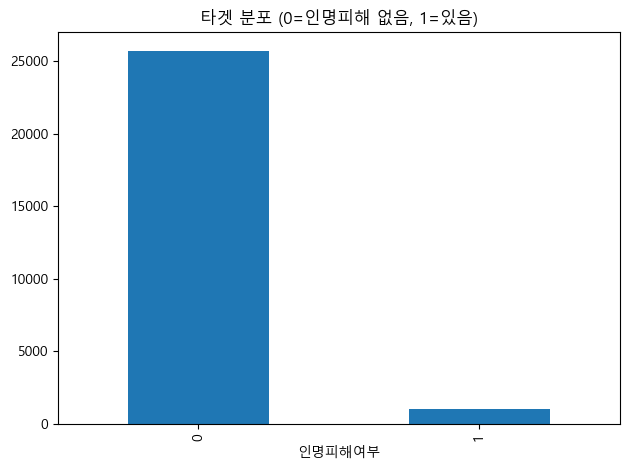

In [2]:
print('[타겟 분포]')
print(df[TARGET].value_counts())
print('인명피해 발생 비율:', round(df[TARGET].mean(), 4))

print('\n[결측치 개수]')
print(df.isnull().sum())

print('\n[범주형 열의 고유값 개수] - 몇 종인지 세어 둬야 인코딩 뒤 폼이 몇 칸이 될지 안다')
for c in ['시군구', '화재유형', '발화요인대분류', '장소대분류', '장소중분류']:
    print('  %-10s %4d종' % (c, df[c].nunique()))

df[TARGET].value_counts().sort_index().plot(kind='bar', title='타겟 분포 (0=인명피해 없음, 1=있음)')
plt.tight_layout(); plt.show()

**관찰 - 여기가 이 실습의 핵심이다**
- 타겟이 **약 96 : 4 로 심하게 불균형**하다. 인명피해가 없는 화재가 대부분이다.
- 이러면 **정확도는 못 믿는다.** 아무 생각 없이 전부 "없음"이라고만 찍어도 정확도가 약 0.96 이 나오기 때문이다.
- 그래서 7단계에서 **ROC-AUC** 로 진짜 실력을 확인한다.

## 3단계. 전처리 - 결측치 처리
날짜에서 **월 · 시간대**를 뽑고, 사용할 열에 결측이 있는 행을 정리한다.

In [3]:
# 날짜에서 월 · 시간대 뽑기 (화재는 계절·시간대의 영향을 받는다)
dt = pd.to_datetime(df['화재발생년원일'], errors='coerce')
df['월']     = dt.dt.month
df['시간대'] = dt.dt.hour

CATS = ['시군구', '화재유형', '발화요인대분류', '장소대분류', '장소중분류']
before = len(df)
df = df.dropna(subset=CATS + ['월', '시간대', TARGET])
print('결측 행 제거: %d행 -> %d행' % (before, len(df)))

결측 행 제거: 26760행 -> 26760행


**중급 포인트 (누수 방지)**
결측을 **중앙값·최빈값으로 채운다면** 전체 데이터가 아니라 **학습 데이터(train) 기준으로** 채워야 한다.
전체 기준으로 채우면 검증 데이터 정보가 학습에 새어 들어가(데이터 누수) 성능이 실제보다 좋아 보인다.

### 2-1. 인사이트 도출 — 데이터가 말하는 것

품질만 보고 넘어가면 안 된다. **모델을 만들기 전에 데이터에게 먼저 물어봐야 한다.**
"어떤 조건일 때 인명피해가 나는가?" 를 **범주별 양성비율**로 집계하면, 숫자가 대답해 준다.

여기서 읽은 것이 나중에 모델이 배운 것과 일치하는지 **7단계에서 대조**한다.

전체 인명피해율 : 3.93%   <- 이 값이 기준선

[화재유형]  상위 3 / 하위 2  (100건 이상 범주만)
   건축,구조물          4.78%   n=20402   기준선의  1.2배
   자동차,철도차량        2.37%   n= 1859   기준선의  0.6배
   기타(쓰레기 화재등)     0.73%   n= 4382   기준선의  0.2배
   기타(쓰레기 화재등)     0.73%   n= 4382   기준선의  0.2배
   임야              0.00%   n=  109   기준선의  0.0배

[발화요인대분류]  상위 3 / 하위 2  (100건 이상 범주만)
   방화             20.07%   n=  274   기준선의  5.1배
   방화의심           18.35%   n=  218   기준선의  4.7배
   미상              8.86%   n= 2471   기준선의  2.3배
   전기적 요인          2.73%   n= 7036   기준선의  0.7배
   기계적 요인          1.91%   n= 1204   기준선의  0.5배

[장소대분류]  상위 3 / 하위 2  (100건 이상 범주만)
   주거              6.05%   n=10587   기준선의  1.5배
   교육시설            5.43%   n=  350   기준선의  1.4배
   산업시설            4.85%   n=  742   기준선의  1.2배
   기타              0.73%   n= 4382   기준선의  0.2배
   임야              0.00%   n=  109   기준선의  0.0배


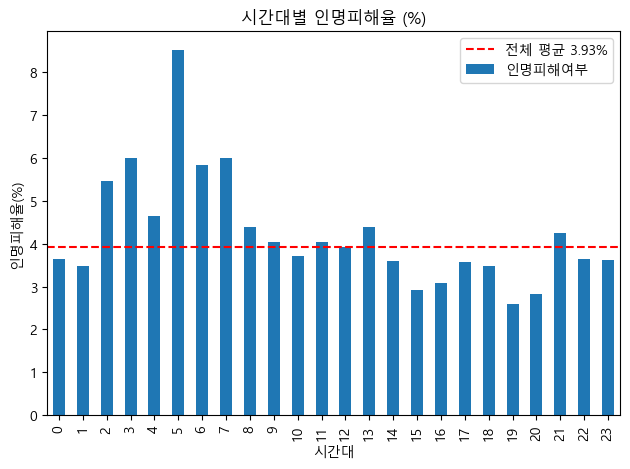

In [4]:
# 범주별 양성비율(인명피해율)을 집계한다. "어떤 조건이 위험한가" 를 수치로 확인.
BASE = df[TARGET].mean()
print('전체 인명피해율 : %.2f%%   <- 이 값이 기준선' % (BASE * 100))

for col in ['화재유형', '발화요인대분류', '장소대분류']:
    t = df.groupby(col)[TARGET].agg(['mean', 'count'])
    t = t[t['count'] >= 100].sort_values('mean', ascending=False)
    print('\n[%s]  상위 3 / 하위 2  (100건 이상 범주만)' % col)
    for name, r in pd.concat([t.head(3), t.tail(2)]).iterrows():
        print('   %-14s %5.2f%%   n=%5d   기준선의 %4.1f배'
              % (str(name)[:14], r['mean'] * 100, r['count'], r['mean'] / BASE))

# 시간대별 인명피해율 — 시간은 숫자라 그래프로 본다
h = df.groupby('시간대')[TARGET].mean() * 100
h.plot(kind='bar', title='시간대별 인명피해율 (%)')
plt.axhline(BASE * 100, color='red', ls='--', label='전체 평균 %.2f%%' % (BASE * 100))
plt.xlabel('시간대'); plt.ylabel('인명피해율(%)')
plt.legend(); plt.tight_layout(); plt.show()

**인사이트 (위 출력에서 읽은 것)**

1. **발화요인이 가장 강하게 갈린다.** `방화` 20.07% · `방화의심` 18.35% 로 기준선(3.93%)의 **약 5배**다.
   반대로 `전기적 요인` 2.73%, `기계적 요인` 1.91% 는 기준선보다 **낮다**.
   → 화재 건수가 많은 요인(전기)과 사람이 다치는 요인(방화)은 **다르다.**
2. **장소는 주거가 위험하다.** `주거` 6.05% (1.5배) vs `기타(쓰레기 화재)` 0.73%.
   사람이 자고 먹는 곳에서 불이 나야 다친다 — 상식과 맞는다.
3. **새벽이 위험하다.** 05시 8.53% vs 19시 2.59% 로 **3배 이상** 차이 난다. 자는 동안은 대피가 늦다.

→ 정리하면 **"새벽에, 주거에서, 방화로 난 불"** 이 가장 위험하다.
이 가설을 모델이 실제로 배우는지 7단계에서 확인한다.

## 4단계. 타겟 분리 & 인코딩
글자로 된 항목을 숫자 코드로 바꾸고, 입력(X)과 정답(y)을 나눈다.

In [5]:
# 글자 -> 코드(숫자). 순서는 feature_spec.json 의 options 배열과 그대로 일치시킨다.
# 코드 열 이름은 영문으로 만든다. 이 이름이 그대로 API 의 JSON 키가 되는데,
# 한글 키는 터미널·도구에 따라 인코딩이 깨져 오류가 나기 때문이다. (보이는 이름은 label 이 담당)
CODE = {'시군구': 'gu', '화재유형': 'fire_type', '발화요인대분류': 'cause',
        '장소대분류': 'place_main', '장소중분류': 'place_sub'}

OPTIONS = {}
for c in CATS:
    OPTIONS[c] = sorted(df[c].unique())
    df[CODE[c]] = df[c].map({v: i for i, v in enumerate(OPTIONS[c])})

df['month'] = df['월']
df['hour']  = df['시간대']

FEATURES = [
    {'name': 'gu',         'label': '자치구',       'kind': 'cat', 'options': OPTIONS['시군구']},
    {'name': 'fire_type',  'label': '화재유형',     'kind': 'cat', 'options': OPTIONS['화재유형']},
    {'name': 'cause',      'label': '발화요인',     'kind': 'cat', 'options': OPTIONS['발화요인대분류']},
    {'name': 'place_main', 'label': '장소(대분류)', 'kind': 'cat', 'options': OPTIONS['장소대분류']},
    {'name': 'place_sub',  'label': '장소(중분류)', 'kind': 'cat', 'options': OPTIONS['장소중분류']},
    {'name': 'month',      'label': '월',           'kind': 'num'},
    {'name': 'hour',       'label': '시간대(0~23)', 'kind': 'num'},
]

X = df[[f['name'] for f in FEATURES]]
y = df[TARGET].astype(int)
print('입력 X:', X.shape, '| 정답 y:', y.shape)
X.head()

입력 X: (26760, 7) | 정답 y: (26760,)


,gu,fire_type,cause,place_main,place_sub,month,hour
0,16,1,7,1,22,1,0
1,7,1,7,1,22,1,2
2,24,0,9,5,33,1,4
3,4,0,7,5,30,1,4
4,20,1,7,1,22,1,5


**중급 포인트 (데이터 누수 - 무엇을 입력에서 빼야 하나)**
`사망`, `부상`, `인명피해(명)소계` 는 **타겟 그 자체**다. 입력에 넣으면 정답을 보고 정답을 맞히는 셈이라 반드시 뺀다.
`재산피해` 도 화재 조사가 끝나야 나오는 **결과값**이라 뺐다. 남긴 7개는 **화재 상황에서 바로 알 수 있는 정보**뿐이다.

**왜 코드 열 이름을 영문으로 하나**: 이 이름이 그대로 **API 의 JSON 키**가 된다. 한글 키는 윈도우 터미널에서 `curl` 로 보낼 때 인코딩이 깨져 `error parsing the body` 가 난다. 화면에 보이는 이름은 `label`(한글)이 따로 담당한다.

**왜 원핫 인코딩이 아닌가**: 02 의 FastAPI 가 `feature_spec.json` 의 `options` **인덱스 번호**를 그대로 받아 예측하기 때문이다.
RandomForest 는 정수 코드로도 구간을 잘 나눈다. 핵심은 **학습할 때의 코드 순서와 서빙할 때의 순서가 같아야 한다**는 것.

## 5단계. 검증 데이터 분할
학습용/검증용으로 나눈다. **불균형 데이터라서 `stratify=y` 가 특히 중요하다** (안 하면 검증에 양성이 거의 안 들어갈 수 있다).

In [6]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print('학습:', X_tr.shape, '| 검증:', X_te.shape)
print('학습 인명피해 비율:', round(y_tr.mean(), 4), '| 검증 인명피해 비율:', round(y_te.mean(), 4))

학습: (21408, 7) | 검증: (5352, 7)
학습 인명피해 비율: 0.0393 | 검증 인명피해 비율: 0.0392


## 6단계. 모델 학습 - 랜덤포레스트
`max_depth=8` 로 깊이를 제한한다(과적합·용량 억제).

**`class_weight='balanced'` 가 이번 실습의 핵심 장치다.** 데이터가 96:4 로 불균형해서, 그냥 학습하면 모델은
"전부 없음"이라고만 답하는 게 이득이라고 배운다. 이 옵션은 **적은 쪽(인명피해 있음)에 가중치를 크게 줘서**
소수 클래스를 제대로 학습하게 만든다. 효과는 7단계에서 직접 비교한다.

In [7]:
model = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42,
                               n_jobs=-1, class_weight='balanced')
model.fit(X_tr, y_tr)
print('학습 완료:', model)

학습 완료: RandomForestClassifier(class_weight='balanced', max_depth=8, n_jobs=-1,
                       random_state=42)


## 7단계. 평가 - 정확도 vs ROC-AUC
**이 단계가 이번 실습의 결론이다.** 정확도와 ROC-AUC 를 함께 보고, 왜 정확도를 믿으면 안 되는지 확인한다.

정확도(Accuracy): 0.7347
  전부 "없음"으로 찍기만 해도 : 0.9608   <- 정확도의 함정
ROC-AUC        : 0.7131   <- 진짜 실력 (0.5 = 찍기)

              precision    recall  f1-score   support

     인명피해 없음       0.97      0.74      0.84      5142
     인명피해 있음       0.08      0.53      0.14       210

    accuracy                           0.73      5352
   macro avg       0.53      0.64      0.49      5352
weighted avg       0.94      0.73      0.82      5352



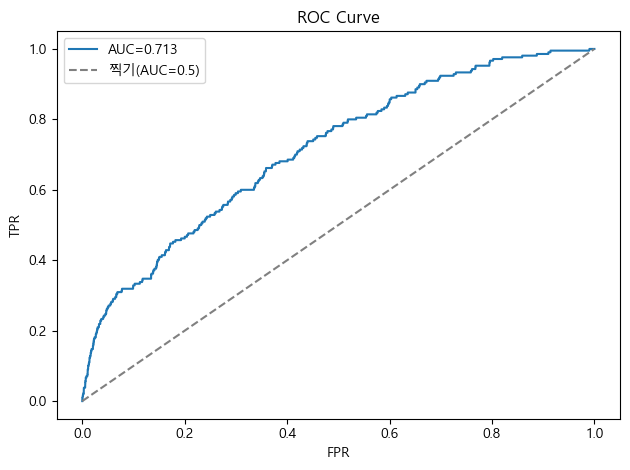

In [8]:
pred  = model.predict(X_te)
proba = model.predict_proba(X_te)[:, 1]      # 양성(인명피해 있음) 확률 열

acc = accuracy_score(y_te, pred)
auc = roc_auc_score(y_te, proba)
base = 1 - y_te.mean()                       # 전부 '없음'으로만 찍었을 때의 정확도

print('정확도(Accuracy):', round(acc, 4))
print('  전부 "없음"으로 찍기만 해도 :', round(base, 4), '  <- 정확도의 함정')
print('ROC-AUC        :', round(auc, 4), '  <- 진짜 실력 (0.5 = 찍기)')
print()
print(classification_report(y_te, pred, target_names=LABELS, zero_division=0))

fpr, tpr, _ = roc_curve(y_te, proba)
plt.plot(fpr, tpr, label='AUC=%.3f' % auc)
plt.plot([0, 1], [0, 1], '--', color='gray', label='찍기(AUC=0.5)')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Curve')
plt.legend(); plt.tight_layout(); plt.show()

### 비교 : `class_weight='balanced'` 를 빼면 어떻게 되나
같은 데이터·같은 설정에서 이 옵션만 빼고 학습해 비교해 본다. **불균형 실습의 핵심 장면이다.**

In [9]:
plain = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
plain.fit(X_tr, y_tr)
p_pred  = plain.predict(X_te)
p_proba = plain.predict_proba(X_te)[:, 1]

rep_p = classification_report(y_te, p_pred, target_names=LABELS, zero_division=0, output_dict=True)
rep_b = classification_report(y_te, pred,   target_names=LABELS, zero_division=0, output_dict=True)

print('%-22s %10s %10s' % ('', 'balanced 안씀', 'balanced 씀'))
print('%-22s %10.4f %10.4f' % ('정확도',              accuracy_score(y_te, p_pred), acc))
print('%-22s %10.4f %10.4f' % ('ROC-AUC',             roc_auc_score(y_te, p_proba), auc))
print('%-22s %10.3f %10.3f' % ("'있음' recall",        rep_p[LABELS[1]]['recall'],    rep_b[LABELS[1]]['recall']))
print('%-22s %10d %10d' % ("'있음' 이라고 예측한 수", int(p_pred.sum()), int(pred.sum())))
print('%-22s %10d %10d' % ('실제 있음 건수',           int(y_te.sum()), int(y_te.sum())))

                       balanced 안씀 balanced 씀
정확도                        0.9609     0.7347
ROC-AUC                    0.7272     0.7131
'있음' recall                 0.005      0.529
'있음' 이라고 예측한 수                  1       1432
실제 있음 건수                      210        210


**결과 해석 - 이번 실습에서 꼭 가져갈 것**
- `balanced` 를 안 쓰면 **정확도는 0.96 으로 훨씬 높은데, 실제 인명피해 화재 210건 중 1건만 잡는다**(recall ≈ 0.005).
  정확도가 높은 이유는 단순하다. **전부 "없음"이라고 찍었기 때문**이다. 이런 모델은 현장에서 아무 쓸모가 없다.
- `balanced` 를 쓰면 정확도는 0.79 로 **떨어지지만 절반가량(recall ≈ 0.49)을 잡아낸다.** 대신 헛경보(precision 낮음)가 늘어난다.
  인명 안전에서는 **놓치는 것(FN)이 헛경보(FP)보다 훨씬 위험**하므로 이 교환이 타당하다.
- **정확도는 착시**다. 불균형 데이터에서는 **ROC-AUC 와 소수 클래스의 recall** 을 봐야 한다.

### 7-2. 인사이트 대조 — 데이터에서 읽은 것을 모델도 배웠나

[특성 중요도] 모델이 실제로 많이 쓴 입력
   cause        0.270
   place_sub    0.169
   fire_type    0.131
   hour         0.125
   place_main   0.117
   gu           0.103
   month        0.085


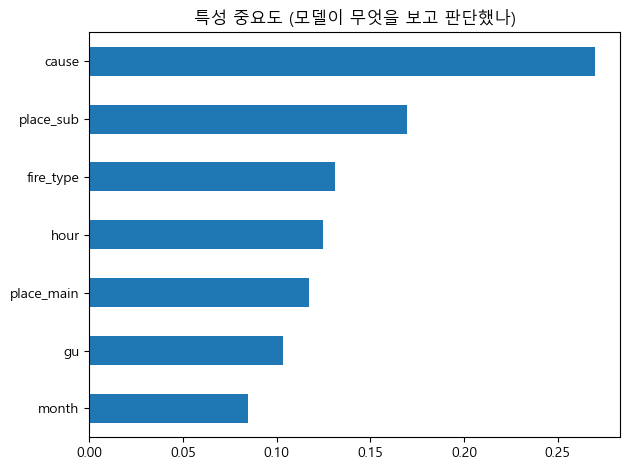

In [10]:
# 2단계에서 데이터로 읽은 인사이트를, 모델이 실제로 그렇게 배웠는지 대조한다.
imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print('[특성 중요도] 모델이 실제로 많이 쓴 입력')
for k, v in imp.items():
    print('   %-12s %.3f' % (k, v))

imp.sort_values().plot(kind='barh', title='특성 중요도 (모델이 무엇을 보고 판단했나)')
plt.tight_layout(); plt.show()

**대조 결과**

`cause`(발화요인) **0.270 으로 1위**, 이어서 `place_sub`(장소 중분류) 0.169, `fire_type`(화재유형) 0.131,
`hour`(시간대) 0.125 순이다.

- 2-1단계에서 **양성비율 차이가 가장 컸던 발화요인**(방화 20.07% = 기준선의 5.1배)이 모델에서도 **1위**다.
  → 데이터에서 읽은 것과 모델이 배운 것이 **일치한다.**
- `hour` 도 상위권이다. 2-1단계에서 05시 8.53% vs 19시 2.59% 로 3배 차이를 본 것과 맞는다.
- `month`(월) 0.085 는 꼴찌다. 화재는 겨울에 많지만, **많이 나는 것과 사람이 다치는 것은 다르다** —
  2단계에서 본 "정확도의 함정" 과 같은 구조의 얘기다.

**인사이트와 모델이 어긋난다면** 둘 중 하나가 틀린 것이니 전처리나 타겟 정의를 다시 봐야 한다.

## 8단계. 모델 저장
학습된 모델(`model.pkl`)과 입력 정의(`feature_spec.json`)를 **02 폴더**에 저장한다.
`feature_spec.json` 은 02 의 API 와 03 의 입력 화면을 자동으로 만드는 데 쓰인다.

**중요**: `model.pkl` 은 **저장할 때의 라이브러리 버전에 묶인다.** 아래 출력의 버전이 `../02/requirements.txt` 와 다르면 02 서버가 `ModuleNotFoundError` 로 뜨지 않는다.

In [11]:
TITLE = '서울 화재 인명피해 예측'
DESC  = '자치구·화재유형·발화요인·장소·시기를 입력하면 해당 화재에 인명피해(사망·부상)가 발생할지 예측합니다.'

for f in FEATURES:                 # 수치형 입력 범위 자동 계산 (화면 기본값·최소·최대)
    if f['kind'] == 'num':
        s = X[f['name']]
        f.update(min=int(np.floor(s.min())), max=int(np.ceil(s.max())), default=int(round(s.median())))

spec = {'title': TITLE, 'description': DESC, 'target_labels': LABELS,
        'accuracy': round(float(acc), 4), 'roc_auc': round(float(auc), 4), 'features': FEATURES}

joblib.dump(model, '../02/model.pkl')
json.dump(spec, open('../02/feature_spec.json', 'w', encoding='utf-8'), ensure_ascii=False, indent=2)
print('저장 완료: ../02/model.pkl, ../02/feature_spec.json')
# 이 모델을 만든 환경의 버전 (02/requirements.txt 와 같아야 model.pkl 을 읽을 수 있다)
import sklearn, sys
print('--- 이 model.pkl 을 만든 환경 ---')
print('python      :', sys.version.split()[0])
print('numpy       :', np.__version__)
print('pandas      :', pd.__version__)
print('scikit-learn:', sklearn.__version__)
print('joblib      :', joblib.__version__)
print('위 버전이 ../02/requirements.txt 와 다르면 02 서버가 뜨지 않는다.')

저장 완료: ../02/model.pkl, ../02/feature_spec.json
--- 이 model.pkl 을 만든 환경 ---
python      : 3.11.0
numpy       : 2.4.6
pandas      : 3.0.3
scikit-learn: 1.9.0
joblib      : 1.5.3
위 버전이 ../02/requirements.txt 와 다르면 02 서버가 뜨지 않는다.


---
### 정리 (뼈대 워크플로우)
로드 → EDA → 결측치 → 타겟분리·인코딩 → 분할(stratify) → 학습 → 평가(ROC-AUC) → 저장

**이번 실습에서 꼭 가져갈 것**
1. 데이터가 불균형하면 **정확도는 착시**다. ROC-AUC 와 소수 클래스의 recall 을 봐야 한다.
2. 불균형 대응은 `class_weight='balanced'`. 정확도를 내주고 **소수 클래스를 잡는 능력**을 얻는다.
3. 타겟 그 자체(사망·부상)나 사후에 나오는 값(재산피해)은 입력에서 빼야 한다(**누수 방지**).

### 다음 (02)
`../02` 의 **FastAPI** 가 `model.pkl` · `feature_spec.json` 을 읽어 예측 엔드포인트와 예측 이력 CRUD 를 제공한다.
`uvicorn main:app --port 8001` 실행 후 `http://localhost:8001/docs` 에서 확인한다.